# 4.3 Stabkräfte und Visualisierung

In Kapitel 4.2 haben wir das LGS $\mathbf{K} \cdot \vec{u} = \vec{F}$
gelöst und die Knotenverschiebungen sowie Lagerreaktionen berechnet. Jetzt
werten wir diese Ergebnisse weiter aus. Wir berechnen die **Stabkräfte**
und bestimmen, ob die einzelnen Stäbe auf Zug oder Druck beansprucht werden.
Anschließend stellen wir die verformte Lage und die Stabkräfte grafisch dar.

## Lernziele

* [ ] Sie können die **Stabkraft** aus den Knotenverschiebungen berechnen
  und als Zug oder Druck interpretieren.
* [ ] Sie können die verformte Lage eines Fachwerks mit einem
  **Überhöhungsfaktor** visualisieren und den Faktor begründen.
* [ ] Sie können Stabkräfte farblich darstellen und aus der Darstellung
  ablesen, welche Stäbe auf Zug und welche auf Druck beansprucht werden.

## Setup

Zunächst wiederholen wir die Ergebnisse aus Kapitel 4.1 und 4.2.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Materialeigenschaften ---
elastizitaetsmodul = 2.1e11                          # Stahl in N/m²
durchmesser        = 1.0e-2                          # Stabdurchmesser in m
querschnitt        = np.pi * 0.25 * durchmesser**2   # Kreisquerschnitt in m²

# --- Knotenkoordinaten: knoten_pos[n, :] = [x_n, y_n] ---
knoten_pos = np.array([
    [0.0,  0.0],   # Knoten 0: x = 0.0 m, y = 0.0 m
    [1.0,  1.0],   # Knoten 1: x = 1.0 m, y = 1.0 m
    [2.0,  0.0],   # Knoten 2: x = 2.0 m, y = 0.0 m
])
anzahl_knoten = knoten_pos.shape[0]

# --- Lagerknoten ---
lager_indizes = [0, 2]

# --- Konnektivitätsmatrix ---
verbindung = np.zeros((anzahl_knoten, anzahl_knoten))
verbindung[0, 1] = 1
verbindung[1, 2] = 1
verbindung = verbindung + verbindung.T

# --- Kraftvektor ---
kraft_knoten = np.zeros((anzahl_knoten, 2))
kraft_knoten[1, 1] = -5000.   # 5000 N nach unten an Knoten 1
kraft_vektor = kraft_knoten.flatten()

# --- Globale Steifigkeitsmatrix ---
steifigkeit_global = np.zeros((2 * anzahl_knoten, 2 * anzahl_knoten))
for i in range(anzahl_knoten):
    for j in range(i + 1, anzahl_knoten):
        if verbindung[i, j]:
            differenz        = knoten_pos[j] - knoten_pos[i]
            staeblaenge      = np.linalg.norm(differenz)
            winkel           = np.arctan2(differenz[1], differenz[0])
            staebsteifigkeit = elastizitaetsmodul * querschnitt / staeblaenge
            cos_w     = np.cos(winkel)
            sin_w     = np.sin(winkel)
            k_element = staebsteifigkeit * np.array([
                [cos_w**2,       sin_w * cos_w],
                [sin_w * cos_w,  sin_w**2     ],
            ])
            steifigkeit_global[2*i : 2*(i+1), 2*i : 2*(i+1)] += k_element
            steifigkeit_global[2*j : 2*(j+1), 2*j : 2*(j+1)] += k_element
            steifigkeit_global[2*i : 2*(i+1), 2*j : 2*(j+1)] -= k_element
            steifigkeit_global[2*j : 2*(j+1), 2*i : 2*(i+1)] -= k_element

# --- Freie DOFs und Lösung ---
freie_indizes = []
for n in range(anzahl_knoten):
    if n not in lager_indizes:
        freie_indizes.append(n)

freie_dofs = []
for n in freie_indizes:
    freie_dofs.append(2 * n)
    freie_dofs.append(2 * n + 1)
freie_dofs = np.array(freie_dofs)

kraft_reduziert       = kraft_vektor[freie_dofs]
steifigkeit_reduziert = steifigkeit_global[freie_dofs, :][:, freie_dofs]
verschiebung_reduziert = np.linalg.solve(steifigkeit_reduziert, kraft_reduziert)

verschiebung_gesamt = np.zeros(2 * anzahl_knoten)
verschiebung_gesamt[freie_dofs] = verschiebung_reduziert

## Stabkräfte berechnen

Die Knotenverschiebungen aus Kapitel 4.2 sagen uns, wie stark sich das
Fachwerk verformt. Sie sagen uns aber noch nicht, wie stark die einzelnen
Stäbe beansprucht werden. Dazu berechnen wir die **Stabkraft** $F_{ij}$
für jeden Stab.

### Vorgehen

1. **Relativverschiebung projizieren**: Den parallelen Anteil
   $u^{\parallel}$ der Relativverschiebung $\vec{u}_j - \vec{u}_i$
   entlang der Stabachse $\vec{e}$ berechnen.
2. **Stabkraft berechnen**: $F_{ij} = k \cdot u^{\parallel}$.
3. **Vorzeichen interpretieren**: $F_{ij} > 0$ bedeutet Zug (Stab wird
   gestreckt), $F_{ij} < 0$ bedeutet Druck (Stab wird gestaucht).

**Schritt 1 - Relativverschiebung projizieren:**
Wir kennen den Einheitsvektor $\vec{e}$ entlang der Stabachse aus
Kapitel 4.2. Die Projektion der Relativverschiebung auf die Stabachse
gibt die Längenänderung des Stabs:

\begin{equation*}
u^{\parallel} = \vec{e}^\top (\vec{u}_j - \vec{u}_i).
\end{equation*}

In [2]:
# Stabkräfte berechnen und ausgeben
print("Stab  Länge      u_parallel    Stabkraft    Typ")
print("-" * 52)

for i in range(anzahl_knoten):
    for j in range(i + 1, anzahl_knoten):
        if verbindung[i, j]:
            # Geometrie
            differenz        = knoten_pos[j] - knoten_pos[i]
            staeblaenge      = np.linalg.norm(differenz)
            winkel           = np.arctan2(differenz[1], differenz[0])
            staebsteifigkeit = elastizitaetsmodul * querschnitt / staeblaenge

            # Einheitsvektor entlang der Stabachse
            einheitsvektor = np.array([np.cos(winkel), np.sin(winkel)])

            # Verschiebungen der Endknoten
            u_i = verschiebung_gesamt[2 * i : 2 * (i + 1)]
            u_j = verschiebung_gesamt[2 * j : 2 * (j + 1)]

            # Schritt 1: Projektion der Relativverschiebung
            u_parallel = np.dot(einheitsvektor, u_j - u_i)

            # Schritt 2: Stabkraft
            stabkraft = staebsteifigkeit * u_parallel

            # Schritt 3: Vorzeichen
            stabtyp = 'Zug' if stabkraft > 0 else 'Druck'

            # Ausgabe
            print(f"  {i}-{j}   {staeblaenge:.3f} m   "
                  f"{u_parallel*1e3:.4f} mm   "
                  f"{stabkraft:.2f} N   {stabtyp}")

Stab  Länge      u_parallel    Stabkraft    Typ
----------------------------------------------------
  0-1   1.414 m   -0.3032 mm   -3535.53 N   Druck
  1-2   1.414 m   -0.3032 mm   -3535.53 N   Druck


**Schritt 2 und 3 - Stabkraft und Vorzeichen:**
Die Stabkraft $F_{ij} = k \cdot u^{\parallel}$ hat dasselbe Vorzeichen
wie die Projektion $u^{\parallel}$:

* $F_{ij} > 0$: Der Stab wird gestreckt, d.h. er steht unter **Zug**.
* $F_{ij} < 0$: Der Stab wird gestaucht, d.h. er steht unter **Druck**.

Gedrückte Stäbe müssen auf Knicken ausgelegt werden, was eine eigene
Bemessungsaufgabe ist.

### Mini-Übung 1

1. Stab 0-1 und Stab 1-2 haben denselben Betrag der Stabkraft. Warum
   ist das für dieses Fachwerk erwartet? Begründen Sie in einem Satz
   ohne Code.
2. Stehen die Stäbe unter Zug oder Druck? Überprüfen Sie das qualitativ:
   Das Fachwerk hat eine Λ-Form — Knoten 1 ist oben, die Lager unten.
   Wenn Knoten 1 durch die Last nach unten gedrückt wird, werden die
   schrägen Stäbe länger oder kürzer?
3. Verdoppeln Sie die Last auf $-10\,000\,\text{N}$ und berechnen Sie
   die Stabkräfte neu. Um welchen Faktor ändern sie sich, und warum?

In [ ]:
# Code-Zelle

## Verformte Lage visualisieren

Die berechneten Knotenverschiebungen sind typischerweise sehr klein im
Vergleich zur Bauteilgröße. Bei unserem Kranausleger aus Stahl liegen die
Verschiebungen im Bereich von Bruchteilen eines Millimeters, während die
Stäbe einen Meter lang sind. Um die Verformung sichtbar zu machen, stellen
wir sie mit einem **Überhöhungsfaktor** dar: Die Verschiebungen werden mit
einem konstanten Faktor multipliziert, bevor sie zur Ausgangsgeometrie
addiert werden. Die Physik ändert sich dabei nicht.

Die Funktion `zeichne_fachwerk` erweitert die einfache `zeichne_geometrie`
aus Kapitel 4.1 um die verformte Lage. Sie übernimmt denselben Array-Aufbau:
`knoten_pos` und `knoten_verformt` haben beide die Form `(anzahl_knoten, 2)`,
Zeile $n$ enthält die Koordinaten von Knoten $n$.

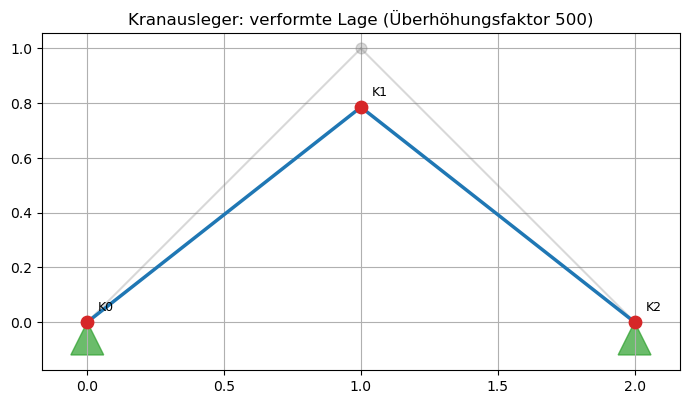

In [3]:
def zeichne_fachwerk(verschiebung=None, skalierung=500, titel=''):
    """Zeichnet das Fachwerk in Ausgangs- und skalierter Verformungslage.

    Hinweis: Zur Vereinfachung greift diese Funktion auf globale Variablen
    (knoten_pos, verbindung, lager_indizes, anzahl_knoten) zu.

    Parameters
    ----------
    verschiebung : ndarray, optional
        Verschiebungsvektor (2*anzahl_knoten,). Standard: keine Verformung.
        Aufbau: [ux_0, uy_0, ux_1, uy_1, ...].
    skalierung : float
        Überhöhungsfaktor für die Darstellung der Verformung.
    titel : str
        Diagrammtitel.
    """
    if verschiebung is None:
        verschiebung = np.zeros(2 * anzahl_knoten)

    fig, ax = plt.subplots(figsize=(7, 4))

    # Knotenposition nach Verformung (überhöht dargestellt)
    # verschiebung.reshape((anzahl_knoten, 2)) hat Form (n, 2) wie knoten_pos
    knoten_verformt = knoten_pos + skalierung * verschiebung.reshape((anzahl_knoten, 2))

    # Stäbe: Ausgangslage grau, verformte Lage blau
    for i in range(anzahl_knoten):
        for j in range(i + 1, anzahl_knoten):
            if verbindung[i, j]:
                ax.plot([knoten_pos[i, 0],      knoten_pos[j, 0]],
                        [knoten_pos[i, 1],      knoten_pos[j, 1]],
                        color='gray', linewidth=1.5, alpha=0.3)
                ax.plot([knoten_verformt[i, 0], knoten_verformt[j, 0]],
                        [knoten_verformt[i, 1], knoten_verformt[j, 1]],
                        color='tab:blue', linewidth=2.5)

    # Knoten: Ausgangslage grau, verformte Lage rot
    ax.scatter(knoten_pos[:, 0],       knoten_pos[:, 1],
               c='gray', s=60, zorder=4, alpha=0.3)
    ax.scatter(knoten_verformt[:, 0],  knoten_verformt[:, 1],
               c='tab:red', s=80, zorder=5)
    for n in range(anzahl_knoten):
        ax.text(knoten_verformt[n, 0] + 0.04, knoten_verformt[n, 1] + 0.04,
                f'K{n}', fontsize=9)

    # Lager als grüne Dreiecke
    h, b = 0.12, 0.12
    for n in lager_indizes:
        x_dreieck = [knoten_verformt[n, 0],
                     knoten_verformt[n, 0] - b / 2,
                     knoten_verformt[n, 0] + b / 2]
        y_dreieck = [knoten_verformt[n, 1],
                     knoten_verformt[n, 1] - h,
                     knoten_verformt[n, 1] - h]
        ax.fill(x_dreieck, y_dreieck, color='tab:green', alpha=0.7)

    ax.set_title(titel)
    ax.set_aspect('equal')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

zeichne_fachwerk(verschiebung=verschiebung_gesamt,
                 skalierung=500,
                 titel='Kranausleger: verformte Lage (Überhöhungsfaktor 500)')

Die grauen Linien und Punkte zeigen die Ausgangslage, die blauen Stäbe
und roten Knoten die verformte Lage. Knoten 1 verschiebt sich sichtbar
nach unten, die Lagerknoten 0 und 2 bleiben an ihrer Position.

### Mini-Übung 2

1. Ändern Sie den Überhöhungsfaktor auf `skalierung=1`. Was sehen Sie,
   und warum?
2. Ändern Sie den Überhöhungsfaktor auf `skalierung=5000`. Beschreiben
   Sie in einem Satz, was sich im Vergleich zu `skalierung=500` ändert
   und was gleich bleibt.

In [ ]:
# Code-Zelle

## Stabkräfte farblich darstellen

Die tabellarische Ausgabe der Stabkräfte ist für kleine Fachwerke übersichtlich.
Bei größeren Fachwerken mit vielen Stäben ist eine farbliche Darstellung
deutlich informativer: Zugstäbe werden blau, Druckstäbe rot eingefärbt, und
die Stabkraft wird als Beschriftung auf dem Stab angezeigt.

Wir definieren dazu eine eigene Funktion `zeichne_fachwerk_kraefte`, die
zusätzlich ein Dictionary mit den Stabkräften entgegennimmt.

In [4]:
def zeichne_fachwerk_kraefte(verschiebung=None, skalierung=500,
                              stabkraefte=None, titel=''):
    """Zeichnet das Fachwerk mit farblich kodierten Stabkräften.

    Parameters
    ----------
    verschiebung : ndarray, optional
        Verschiebungsvektor (2*anzahl_knoten,). Standard: keine Verformung.
    skalierung : float
        Überhöhungsfaktor für die Darstellung der Verformung.
    stabkraefte : dict, optional
        Dictionary mit Stabkräften: {(i, j): F_ij in N}.
        F_ij > 0: Zug (blau), F_ij < 0: Druck (rot).
    titel : str
        Diagrammtitel.
    """
    if verschiebung is None:
        verschiebung = np.zeros(2 * anzahl_knoten)
    if stabkraefte is None:
        stabkraefte = {}

    fig, ax = plt.subplots(figsize=(7, 4))

    # Verformte Knotenpositionen
    knoten_verformt = knoten_pos + skalierung * verschiebung.reshape((anzahl_knoten, 2))

    # Stäbe: farblich nach Zug (blau) oder Druck (rot)
    for i in range(anzahl_knoten):
        for j in range(i + 1, anzahl_knoten):
            if verbindung[i, j]:
                # Ausgangslage grau
                ax.plot([knoten_pos[i, 0],      knoten_pos[j, 0]],
                        [knoten_pos[i, 1],      knoten_pos[j, 1]],
                        color='gray', linewidth=1.5, alpha=0.3)

                # Farbe nach Vorzeichen der Stabkraft
                F = stabkraefte.get((i, j), 0)
                farbe = 'tab:blue' if F >= 0 else 'tab:red'

                ax.plot([knoten_verformt[i, 0], knoten_verformt[j, 0]],
                        [knoten_verformt[i, 1], knoten_verformt[j, 1]],
                        color=farbe, linewidth=3.5)

                # Stabkraft als Beschriftung mittig auf dem Stab
                mx = 0.5 * (knoten_verformt[i, 0] + knoten_verformt[j, 0])
                my = 0.5 * (knoten_verformt[i, 1] + knoten_verformt[j, 1])
                ax.text(mx, my + 0.08,
                        f'{F/1000:.2f} kN',
                        fontsize=8, ha='center', color=farbe)

    # Knoten
    ax.scatter(knoten_pos[:, 0],      knoten_pos[:, 1],
               c='gray', s=60, zorder=4, alpha=0.3)
    ax.scatter(knoten_verformt[:, 0], knoten_verformt[:, 1],
               c='tab:red', s=80, zorder=5)
    for n in range(anzahl_knoten):
        ax.text(knoten_verformt[n, 0] + 0.04,
                knoten_verformt[n, 1] + 0.04,
                f'K{n}', fontsize=9)

    # Lager als grüne Dreiecke
    h, b = 0.12, 0.12
    for n in lager_indizes:
        x_dreieck = [knoten_verformt[n, 0],
                     knoten_verformt[n, 0] - b / 2,
                     knoten_verformt[n, 0] + b / 2]
        y_dreieck = [knoten_verformt[n, 1],
                     knoten_verformt[n, 1] - h,
                     knoten_verformt[n, 1] - h]
        ax.fill(x_dreieck, y_dreieck, color='tab:green', alpha=0.7)

    # Legende
    ax.plot([], [], color='tab:blue', linewidth=3, label='Zug')
    ax.plot([], [], color='tab:red',  linewidth=3, label='Druck')
    ax.legend(fontsize=9, loc='upper right')

    ax.set_title(titel)
    ax.set_aspect('equal')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

Wir rufen die Funktion mit den berechneten Stabkräften auf. Dazu sammeln
wir die Stabkräfte zuerst in einem Dictionary.

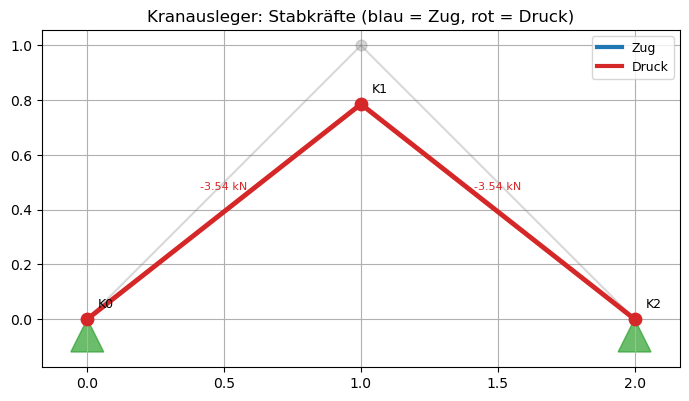

In [5]:
# Stabkräfte berechnen und in Dictionary speichern
stabkraefte = {}
for i in range(anzahl_knoten):
    for j in range(i + 1, anzahl_knoten):
        if verbindung[i, j]:
            differenz        = knoten_pos[j] - knoten_pos[i]
            staeblaenge      = np.linalg.norm(differenz)
            winkel           = np.arctan2(differenz[1], differenz[0])
            staebsteifigkeit = elastizitaetsmodul * querschnitt / staeblaenge
            einheitsvektor   = np.array([np.cos(winkel), np.sin(winkel)])
            u_i              = verschiebung_gesamt[2 * i : 2 * (i + 1)]
            u_j              = verschiebung_gesamt[2 * j : 2 * (j + 1)]
            u_parallel       = np.dot(einheitsvektor, u_j - u_i)
            stabkraefte[(i, j)] = staebsteifigkeit * u_parallel

# Fachwerk mit Stabkräften zeichnen
zeichne_fachwerk_kraefte(verschiebung=verschiebung_gesamt,
                         skalierung=500,
                         stabkraefte=stabkraefte,
                         titel='Kranausleger: Stabkräfte (blau = Zug, rot = Druck)')

### Mini-Übung 3

1. Ändern Sie die Last auf $-10\,000\,\text{N}$ und berechnen Sie die
   Stabkräfte neu. Ändern sich die Farben der Stäbe? Warum oder warum nicht?

2. Fügen Sie einen dritten Stab zwischen Knoten 0 und Knoten 2 ein
   (`verbindung[0, 2] = 1; verbindung[2, 0] = 1`). Berechnen Sie die
   Steifigkeitsmatrix, die Verschiebungen und die Stabkräfte neu.
   Welche Stabkraft ergibt sich für den neuen Stab, und warum?

In [ ]:
# Code-Zelle

## Zusammenfassung und Ausblick

Wir haben die Knotenverschiebungen aus Kapitel 4.2 genutzt, um die
Stabkräfte zu berechnen, die verformte Lage darzustellen und Zug- und
Druckstäbe farblich zu unterscheiden. Die Stabkraft $F_{ij} = k \cdot u^{\parallel}$
folgt direkt aus der Projektion der Relativverschiebung auf die Stabachse:
positives Vorzeichen bedeutet Zug (Stab wird gestreckt), negatives Vorzeichen
bedeutet Druck (Stab wird gestaucht). Druckstäbe müssen in der Praxis auf
Knicken nachgewiesen werden.

Im nächsten Kapitel wenden wir denselben Algorithmus auf größere Tragwerke mit
mehr Knoten und Stäben an. Der Algorithmus bleibt derselbe, nur die Matrizen und
Vektoren werden größer.